In [8]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

# for importing data
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset

import os
import sys
from PIL import Image

import matplotlib.pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Import the data


In [10]:
# transformations
transform = T.Compose(
    [
        T.Resize(64),
        T.CenterCrop(64),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)


# custom dataset class to load face images
class faceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []

        valid_exts = (".jpg", ".jpeg", ".png")
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(valid_exts):
                    self.image_paths.append(os.path.join(root, file))

        self.image_paths.sort()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


# download CelebA dataset
import kagglehub

dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
celeba_subpath = os.path.join(dataset_path, "img_align_celeba", "img_align_celeba")
if os.path.exists(celeba_subpath):
    dataset_path = celeba_subpath

dataset = faceDataset(root_dir=dataset_path, transform=transform)

# transform to dataloader
batchsize = 128
data_loader = DataLoader(dataset, batch_size=batchsize, shuffle=True, drop_last=True)

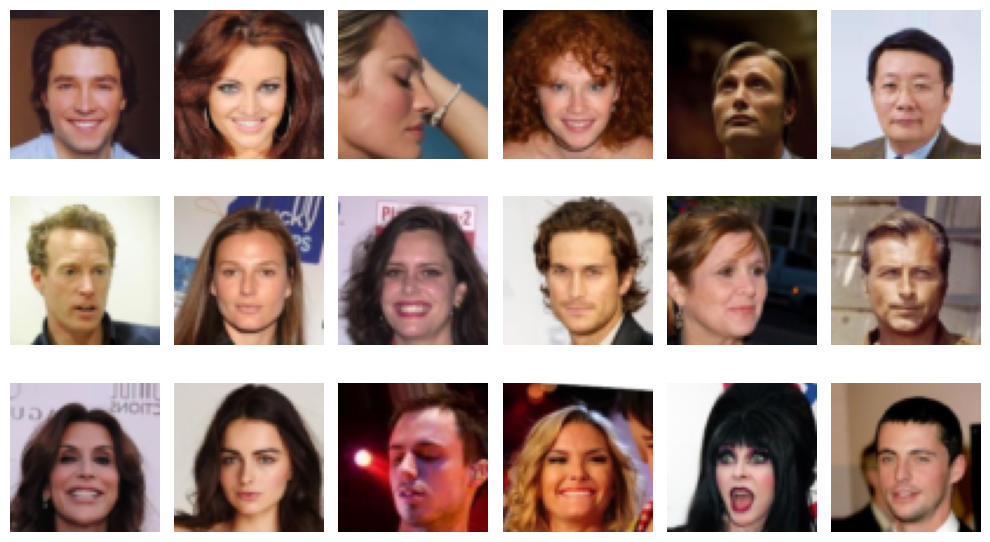

In [11]:
# view some images
X = next(iter(data_loader))

fig, axs = plt.subplots(3, 6, figsize=(10, 6))

for i, ax in enumerate(axs.flatten()):

    # extract that image
    pic = np.transpose(X[i].numpy(), (1, 2, 0))
    pic = pic / 2 + 0.5  # undo normalization

    # and show!
    ax.imshow(np.clip(pic, 0, 1))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Create classes for the discriminator and generator


In [12]:
class discriminatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        # convolution layers
        self.conv1 = nn.Conv2d(3, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)
        self.conv5 = nn.Conv2d(512, 1, 4, 1, 0, bias=False)

        # batchnorm
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = self.bn2(x)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = self.bn3(x)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = self.bn4(x)
        return torch.sigmoid(self.conv5(x)).view(-1, 1)


dnet = discriminatorNet()
y = dnet(torch.randn(10, 3, 64, 64))
y.shape

torch.Size([10, 1])

torch.Size([10, 3, 64, 64])


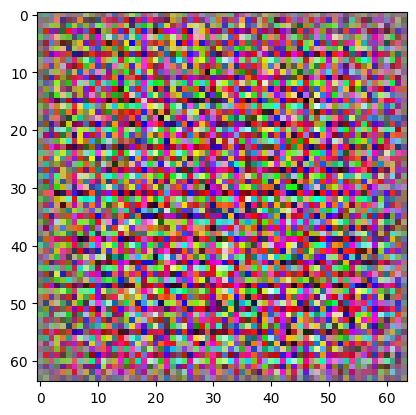

In [ ]:
class generatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        # convolution layers
        self.conv1 = nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False)
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.conv5 = nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False)

        # batchnorm
        self.bn1 = nn.BatchNorm2d(512)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = torch.tanh(self.conv5(x))
        return x


gnet = generatorNet()
y = gnet(torch.randn(10, 100, 1, 1))
print(y.shape)
plt.imshow((np.transpose(y[0].detach().numpy(), (1, 2, 0)) / 2 + 0.5).clip(0, 1))

plt.show()

# Train the models!


In [14]:
lossfun = nn.BCELoss()

dnet = discriminatorNet().to(device)
gnet = generatorNet().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [15]:
# training parameters and initializations
num_epochs = 25
losses = []
disDecs = []

for epochi in range(num_epochs):

    for data in data_loader:

        # send data to GPU
        data = data.to(device)
        bsize = data.shape[0]

        # create labels for real and fake images
        real_labels = torch.ones(bsize, 1).to(device)
        fake_labels = torch.zeros(bsize, 1).to(device)

        ### Train the discriminator ###

        # forward pass and loss for REAL pictures
        pred_real = dnet(data)  # output of discriminator
        d_loss_real = lossfun(pred_real, real_labels)  # all labels are 1

        # forward pass and loss for FAKE pictures
        fake_data = torch.randn(bsize, 100, 1, 1).to(
            device
        )  # random numbers to seed the generator
        fake_images = gnet(fake_data)  # output of generator
        pred_fake = dnet(fake_images)  # pass through discriminator
        d_loss_fake = lossfun(pred_fake, fake_labels)  # all labels are 0

        # collect loss (using combined losses)
        d_loss = d_loss_real + d_loss_fake

        # backprop
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        ### Train the generator ###

        # create fake images and compute loss
        fake_images = gnet(torch.randn(bsize, 100, 1, 1).to(device))
        pred_fake = dnet(fake_images)

        # compute loss
        g_loss = lossfun(pred_fake, real_labels)

        # backprop
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # collect losses and discriminator decisions
        losses.append([d_loss.item(), g_loss.item()])

        d1 = torch.mean((pred_real > 0.5).float()).detach()
        d2 = torch.mean((pred_fake > 0.5).float()).detach()
        disDecs.append([d1.detach().cpu().item(), d2.detach().cpu().item()])

    # print out a status message
    msg = f"Finished epoch {epochi+1}/{num_epochs}"
    sys.stdout.write("\r" + msg)


# convert performance from list to numpy array
losses = np.array(losses)
disDecs = np.array(disDecs)

Finished epoch 6/25

: 

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(losses[:, 0])
ax[0].plot(losses[:, 1])
ax[0].set_xlabel("Batches")
ax[0].set_ylabel("Loss")
ax[0].set_title("Model loss")
ax[0].legend(["Discrimator", "Generator"])

ax[1].plot(losses[::5, 0], losses[::5, 1], "k.", alpha=0.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(disDecs[:, 0])
ax[2].plot(disDecs[:, 1])
ax[2].set_xlabel("Epochs")
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title("Discriminator output")
ax[2].legend(["Real", "Fake"])

plt.show()

# Let's see some generated faces!


In [ ]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(18, 100, 1, 1).to(device)).cpu()

# and visualize
fig, axs = plt.subplots(3, 6, figsize=(12, 6))
for i, ax in enumerate(axs.flatten()):
    pic = np.transpose(fake_data[i,].detach().numpy(), (1, 2, 0))
    pic = pic / 2 + 0.5
    ax.imshow(np.clip(pic, 0, 1))
    ax.axis("off")

plt.show()

# Latent space interpolation (face morphing)


In [ ]:
# spherical interpolation between two random latent vectors
def slerp(val, low, high):
    low_norm = low / torch.norm(low, dim=1, keepdim=True)
    high_norm = high / torch.norm(high, dim=1, keepdim=True)
    omega = torch.acos(
        torch.clamp((low_norm * high_norm).sum(dim=1, keepdim=True), -1, 1)
    )
    so = torch.sin(omega)
    if so.item() == 0:
        return (1.0 - val) * low + val * high
    return (torch.sin((1.0 - val) * omega) / so) * low + (
        torch.sin(val * omega) / so
    ) * high


z1 = torch.randn(1, 100, 1, 1).to(device)
z2 = torch.randn(1, 100, 1, 1).to(device)

num_steps = 10
fig, axs = plt.subplots(1, num_steps, figsize=(15, 2.5))

for step_idx, alpha in enumerate(np.linspace(0, 1, num_steps)):
    z_interp = slerp(alpha, z1.view(1, -1), z2.view(1, -1)).view(1, 100, 1, 1)
    img = gnet(z_interp).detach().cpu().squeeze()
    pic = np.transpose(img.numpy(), (1, 2, 0))
    pic = np.clip(pic / 2 + 0.5, 0, 1)

    axs[step_idx].imshow(pic)
    axs[step_idx].axis("off")

plt.show()